# Ranges Poker 8-max MTT — Analyse & Contrôle Qualité

**Du PDF de stratégie au dashboard interactif : un pipeline de données complet.**

Ce notebook explore un jeu de données de ranges préflop en tournoi (8-max, 4 profondeurs
de tapis), extrait d'un PDF par pixel-parsing et enrichi de positions approximées et de
paramètres contextuels documentés. L'objectif n'est pas de produire une stratégie poker
parfaite, mais de démontrer une chaîne complète : exploration, contrôles de cohérence en
SQL, et arbitrage argumenté entre défaut de construction et nuance stratégique légitime.

*Détail des hypothèses, sources et limites : voir `README.md` et `limites_et_hypotheses.md`.*

---

Plan : 
1) télécharger le fichier CSV
2) Voir les colonnes et leurs types
3) Voir les différentes valeurs pour chaque colonne
4) Voir le nombre de N/A dans chaque colonne
5) Conduire des analyses spécifiques sur les ranges de Winamax / sur les approximations / sur les variables ajoutées / vérifier l'impact de la bulle à venir pour les différentes profondeurs de tapis / voir pour les mains de défense comment il s'est adapté à chaque position / analyser écart dû au contexte que j'ai ajouté

In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv('ranges_mtt_8max.csv')

In [3]:
df.shape

(243360, 15)

In [4]:
df.info() #Pas de null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243360 entries, 0 to 243359
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Main                243360 non-null  object
 1   TypeMain            243360 non-null  object
 2   Combos              243360 non-null  int64 
 3   RangForce           243360 non-null  int64 
 4   Position            243360 non-null  object
 5   TypeAction          243360 non-null  object
 6   StackBB             243360 non-null  object
 7   AggressiviteTable   243360 non-null  object
 8   BulleAVenir         243360 non-null  object
 9   VitesseBlindes      243360 non-null  object
 10  StructurePrix       243360 non-null  object
 11  ActionBase          243360 non-null  object
 12  ActionFinale        243360 non-null  object
 13  SourceDonnee        243360 non-null  object
 14  ModifieParContexte  243360 non-null  object
dtypes: int64(2), object(13)
memory usage: 27.9+ MB


In [5]:
df.head()

,Main,TypeMain,Combos,RangForce,Position,TypeAction,StackBB,AggressiviteTable,BulleAVenir,VitesseBlindes,StructurePrix,ActionBase,ActionFinale,SourceDonnee,ModifieParContexte
0,AA,paire,6,1,UTG_UTG1,Open,15-19bb,Loose,Non,Lente,Flat,RAISE_4BET,RAISE_4BET,PDF_Calamusa,Non
1,AKs,suited,4,3,UTG_UTG1,Open,15-19bb,Loose,Non,Lente,Flat,RAISE_4BET,RAISE_4BET,PDF_Calamusa,Non
2,AQs,suited,4,8,UTG_UTG1,Open,15-19bb,Loose,Non,Lente,Flat,RAISE_4BET,RAISE_4BET,PDF_Calamusa,Non
3,AJs,suited,4,11,UTG_UTG1,Open,15-19bb,Loose,Non,Lente,Flat,ALLIN,ALLIN,PDF_Calamusa,Non
4,ATs,suited,4,13,UTG_UTG1,Open,15-19bb,Loose,Non,Lente,Flat,RAISE_FOLD,RAISE_FOLD,PDF_Calamusa,Non


In [6]:
df['TypeAction'].value_counts() #Sert juste à différencier toutes les positions de la défense BB

TypeAction
Open          146016
Defense_BB     97344
Name: count, dtype: int64

In [7]:
df.columns

Index(['Main', 'TypeMain', 'Combos', 'RangForce', 'Position', 'TypeAction',
       'StackBB', 'AggressiviteTable', 'BulleAVenir', 'VitesseBlindes',
       'StructurePrix', 'ActionBase', 'ActionFinale', 'SourceDonnee',
       'ModifieParContexte'],
      dtype='object')

In [8]:
df.describe()

,Combos,RangForce
count,243360.000000,243360.000000
mean,7.846154,85.000000
std,3.879860,48.785344
min,4.000000,1.000000
25%,4.000000,43.000000
50%,6.000000,85.000000
75%,12.000000,127.000000
max,12.000000,169.000000


In [9]:
df['Main'].unique()

array(['AA', 'AKs', 'AQs', 'AJs', 'ATs', 'A9s', 'A8s', 'A7s', 'A6s',
       'A5s', 'A4s', 'A3s', 'A2s', 'KK', 'KQs', 'KJs', 'KTs', 'K9s',
       'K8s', 'K7s', 'K6s', 'K5s', 'K4s', 'K3s', 'K2s', 'QQ', 'QJs',
       'QTs', 'Q9s', 'Q8s', 'Q7s', 'Q6s', 'Q5s', 'Q4s', 'Q3s', 'Q2s',
       'JJ', 'JTs', 'J9s', 'J8s', 'J7s', 'J6s', 'J5s', 'J4s', 'J3s',
       'J2s', 'TT', 'T9s', 'T8s', 'T7s', 'T6s', 'T5s', 'T4s', 'T3s',
       'T2s', '99', '98s', '97s', '96s', '95s', '94s', '93s', '92s', '88',
       '87s', '86s', '85s', '84s', '83s', '82s', '77', '76s', '75s',
       '74s', '73s', '72s', '66', '65s', '64s', '63s', '62s', '55', '54s',
       '53s', '52s', '44', '43s', '42s', '33', '32s', '22', 'AKo', 'AQo',
       'AJo', 'ATo', 'A9o', 'A8o', 'A7o', 'A6o', 'A5o', 'A4o', 'A3o',
       'A2o', 'KQo', 'KJo', 'KTo', 'K9o', 'K8o', 'K7o', 'K6o', 'K5o',
       'K4o', 'K3o', 'K2o', 'QJo', 'QTo', 'Q9o', 'Q8o', 'Q7o', 'Q6o',
       'Q5o', 'Q4o', 'Q3o', 'Q2o', 'JTo', 'J9o', 'J8o', 'J7o', 'J6o',
       'J5o'

ANALYSES SPECIFIQUES

Nombre de mains jouées par position - contexte neutre

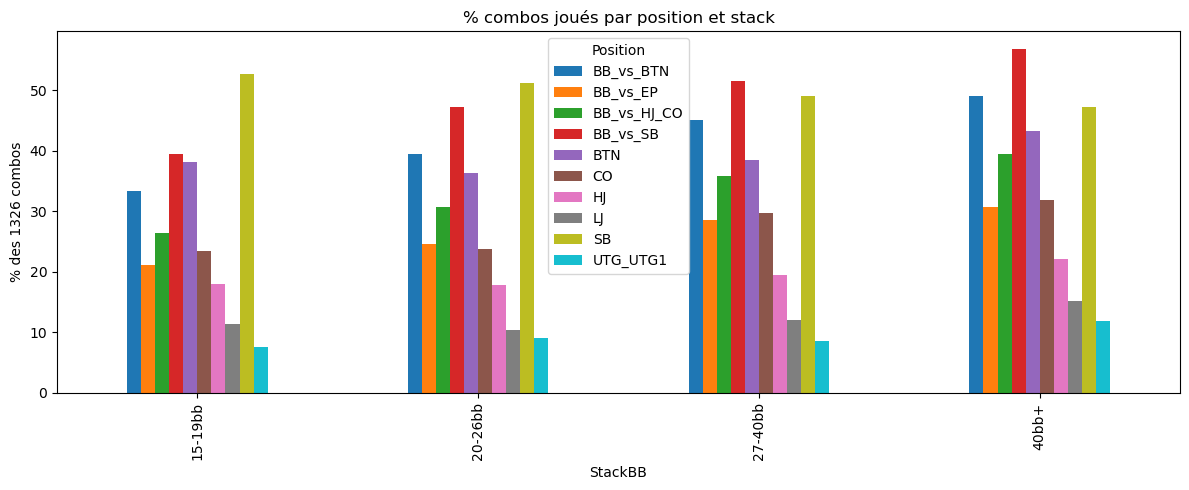

In [10]:
import matplotlib.pyplot as plt

neutre = df[
    (df['AggressiviteTable'] == 'Normale') &
    (df['BulleAVenir'] == 'Non') &
    (df['VitesseBlindes'] == 'Normale') &
    (df['StructurePrix'] == 'Flat')
]

largeur = (
    neutre[neutre['ActionFinale'] != 'FOLD']
    .groupby(['Position', 'StackBB'])['Combos']
    .sum() / 1326 * 100
).reset_index()
largeur.columns = ['Position', 'StackBB', 'Pct_Combos']

pivot = largeur.pivot(index='StackBB', columns='Position', values='Pct_Combos')
pivot.plot(kind='bar', figsize=(12, 5), title='% combos joués par position et stack')
plt.ylabel('% des 1326 combos')
plt.tight_layout()
plt.show()

Range de défense (call + 3-bet face à un adversaire déjà engagé) est structurellement plus large qu'une range d'ouverture. Résultat visuel : les barres BB_vs_SB/BB_vs_BTN écrasent tout le reste. Cohérent

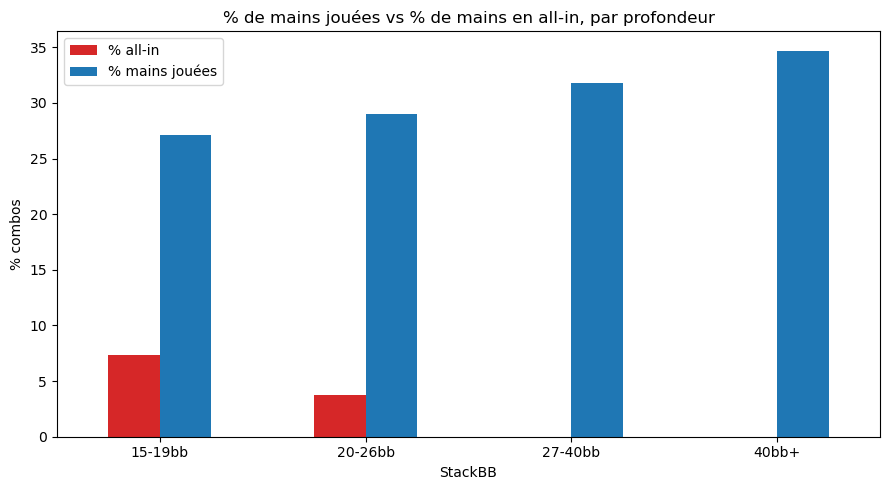

Metrique  % all-in  % mains jouées
StackBB                           
15-19bb   7.330317       27.119155
20-26bb   3.710407       29.019608
27-40bb        NaN       31.809955
40bb+          NaN       34.705882


In [11]:
n_positions = df['Position'].nunique()
allin_actions = ['ALLIN', '3BET_ALLIN']

# % de mains jouées (hors fold)
par_stack = (
    neutre[neutre['ActionFinale'] != 'FOLD']
    .groupby('StackBB')['Combos']
    .sum().div(1326 * n_positions).mul(100)
    .reset_index(name='Pct_Combos')
)
par_stack['Metrique'] = '% mains jouées'
par_stack = par_stack.rename(columns={'Pct_Combos': 'Valeur'})

# % de mains en all-in
par_stack_allin = (
    neutre[neutre['ActionFinale'].isin(allin_actions)]
    .groupby('StackBB')['Combos']
    .sum().div(1326 * n_positions).mul(100)
    .reset_index(name='Pct_AllIn')
)
par_stack_allin['Metrique'] = '% all-in'
par_stack_allin = par_stack_allin.rename(columns={'Pct_AllIn': 'Valeur'})

# fusion des deux
combine = pd.concat([par_stack, par_stack_allin], ignore_index=True)

ordre_stack = ['15-19bb', '20-26bb', '27-40bb', '40bb+']
combine['StackBB'] = pd.Categorical(combine['StackBB'], categories=ordre_stack, ordered=True)
combine = combine.sort_values('StackBB')

pivot_combine = combine.pivot(index='StackBB', columns='Metrique', values='Valeur')

pivot_combine.plot(kind='bar', figsize=(9, 5),
                    color={'% mains jouées': '#1f77b4', '% all-in': '#d62728'},
                    title='% de mains jouées vs % de mains en all-in, par profondeur')
plt.ylabel('% combos')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()

print(pivot_combine)

Logique : plus on est short, moins on joue de mains et moins on veut voir de flop, on se commit rapidement. 

Impact de la bulle par profondeur de tapis

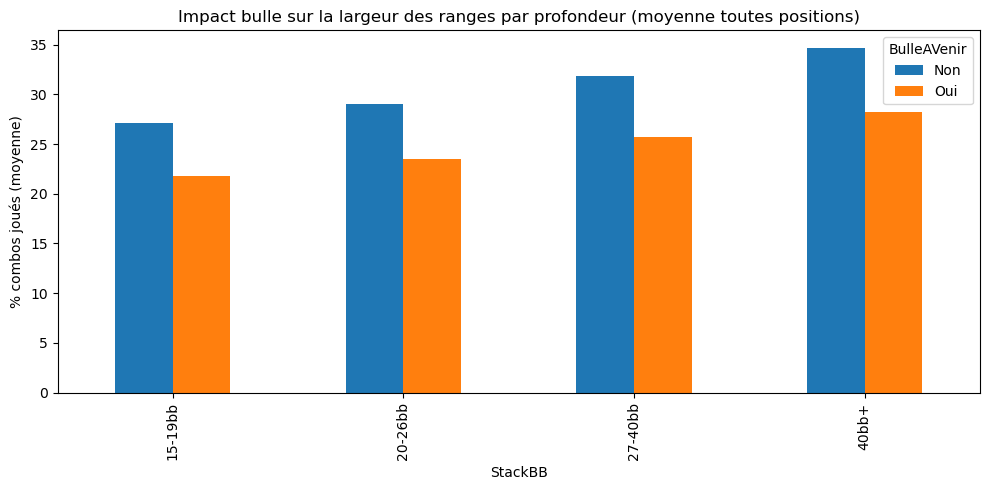

BulleAVenir  Ecart_pts
StackBB               
15-19bb       5.309201
20-26bb       5.520362
27-40bb       6.078431
40bb+         6.485671


In [12]:
neutre_sans_bulle = df[
    (df['AggressiviteTable'] == 'Normale') &
    (df['VitesseBlindes'] == 'Normale') &
    (df['StructurePrix'] == 'Flat')
]

bulle = (
    neutre_sans_bulle[neutre_sans_bulle['ActionFinale'] != 'FOLD']
    .groupby(['BulleAVenir', 'StackBB'])['Combos']
    .sum()
    .div(1326 * n_positions)
    .mul(100)
    .reset_index()
)
bulle.columns = ['BulleAVenir', 'StackBB', 'Pct_Combos']

pivot_bulle = bulle.pivot(index='StackBB', columns='BulleAVenir', values='Pct_Combos')

pivot_bulle.plot(kind='bar', figsize=(10, 5),
                 title='Impact bulle sur la largeur des ranges par profondeur (moyenne toutes positions)')
plt.ylabel('% combos joués (moyenne)')
plt.tight_layout()
plt.show()

pivot_bulle['Ecart_pts'] = pivot_bulle['Non'] - pivot_bulle['Oui']
print(pivot_bulle[['Ecart_pts']])

l'écart bulle grandit avec le stack (5,3 pts à 15-19bb → 6,5 pts à 40bb+), cohérent avec la théorie ICM — plus tu as de stack (donc plus à perdre relativement), plus l'ajustement de survie pèse en bulle. Par contre si on a une table très tight avant la bulle ça peut être intéressant de profiter de sa profondeur pour élargir ses ranges et le modèle ne prend pas ça en compte. 

Défense BB - adaptation selon la position de l'open

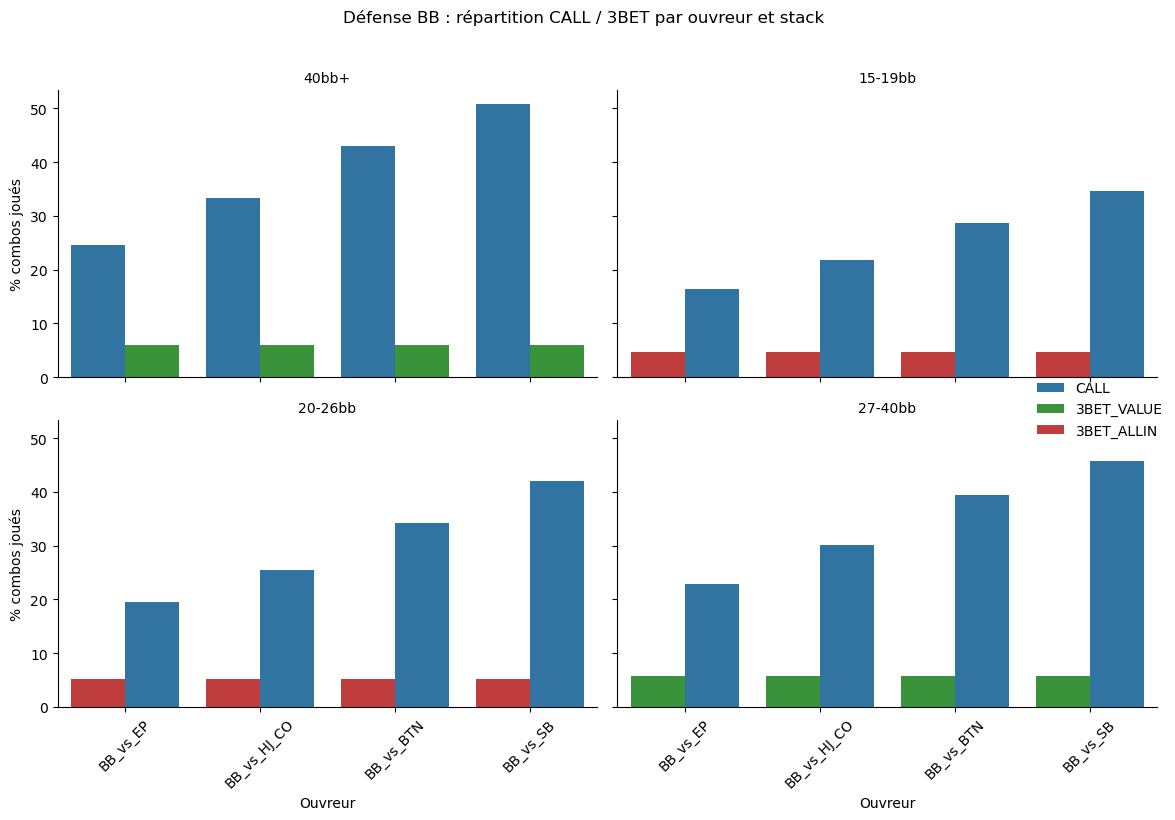

In [13]:
bb = df[
    df['Position'].str.startswith('BB') &
    (df['AggressiviteTable'] == 'Normale') &
    (df['BulleAVenir'] == 'Non') &
    (df['VitesseBlindes'] == 'Normale') &
    (df['StructurePrix'] == 'Flat')
]

defense = (
    bb[bb['ActionFinale'] != 'FOLD']
    .groupby(['Position', 'StackBB', 'ActionFinale'])['Combos']
    .sum().div(1326).mul(100)
    .reset_index(name='Pct_Combos')
)

ordre = ['BB_vs_EP', 'BB_vs_HJ_CO', 'BB_vs_BTN', 'BB_vs_SB']
defense['Position'] = pd.Categorical(defense['Position'], categories=ordre, ordered=True)
defense = defense.sort_values('Position')

import seaborn as sns
g = sns.FacetGrid(defense, col='StackBB', col_wrap=2, height=4, aspect=1.3)
g.map_dataframe(sns.barplot, x='Position', y='Pct_Combos', hue='ActionFinale',
                 palette={'CALL': '#1f77b4', '3BET_VALUE': '#2ca02c', '3BET_ALLIN': '#d62728'})
g.add_legend()
g.set_titles('{col_name}')
g.set_axis_labels('Ouvreur', '% combos joués')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Défense BB : répartition CALL / 3BET par ouvreur et stack', y=1.02)
plt.tight_layout()
plt.show()

La progression EP→HJ_CO→BTN→SB est logique (on défend plus large contre un ouvreur qui ouvre plus large, exactement ce qu'un joueur ferait en exploitant l'agressivité adverse).

Défaut : les segments rouge/vert (3BET_ALLIN / 3BET_VALUE) devraient être quasi identiques en hauteur absolue entre les 4 positions d'un même panel.  Le modèle fait varier la largeur de call selon l'ouvreur, mais pas la largeur de 3-bet => vraie faiblesse du modèle. 

On prépare ci-dessous les colonnes nécessaires à la matrice 13×13 dans Power BI

In [14]:
ORDRE = ['A','K','Q','J','T','9','8','7','6','5','4','3','2']
RANK_IDX = {r: i+1 for i, r in enumerate(ORDRE)}  # A=1 ... 2=13

def rang1(main): return main[0]
def rang2(main): return main[0] if len(main) == 2 else main[1]

df['Rang1'] = df['Main'].apply(rang1)
df['Rang2'] = df['Main'].apply(rang2)
df['Idx1'] = df['Rang1'].map(RANK_IDX)
df['Idx2'] = df['Rang2'].map(RANK_IDX)

df['RowRank'] = df.apply(lambda r: r['Idx2'] if r['TypeMain']=='offsuit' else r['Idx1'], axis=1)
df['ColRank'] = df.apply(lambda r: r['Idx1'] if r['TypeMain']=='offsuit' else r['Idx2'], axis=1)
df['RowLabel'] = df.apply(lambda r: r['Rang2'] if r['TypeMain']=='offsuit' else r['Rang1'], axis=1)
df['ColLabel'] = df.apply(lambda r: r['Rang1'] if r['TypeMain']=='offsuit' else r['Rang2'], axis=1)

df.to_csv('V2_ranges_mtt_8max_enrichi.csv', index=False)

In [15]:
df.head()

,Main,TypeMain,Combos,RangForce,Position,TypeAction,StackBB,AggressiviteTable,BulleAVenir,VitesseBlindes,...,SourceDonnee,ModifieParContexte,Rang1,Rang2,Idx1,Idx2,RowRank,ColRank,RowLabel,ColLabel
0,AA,paire,6,1,UTG_UTG1,Open,15-19bb,Loose,Non,Lente,...,PDF_Calamusa,Non,A,A,1,1,1,1,A,A
1,AKs,suited,4,3,UTG_UTG1,Open,15-19bb,Loose,Non,Lente,...,PDF_Calamusa,Non,A,K,1,2,1,2,A,K
2,AQs,suited,4,8,UTG_UTG1,Open,15-19bb,Loose,Non,Lente,...,PDF_Calamusa,Non,A,Q,1,3,1,3,A,Q
3,AJs,suited,4,11,UTG_UTG1,Open,15-19bb,Loose,Non,Lente,...,PDF_Calamusa,Non,A,J,1,4,1,4,A,J
4,ATs,suited,4,13,UTG_UTG1,Open,15-19bb,Loose,Non,Lente,...,PDF_Calamusa,Non,A,T,1,5,1,5,A,T


In [16]:
!pip install duckdb

In [17]:
import duckdb

con = duckdb.connect('poker_ranges.duckdb')  # crée un fichier local, réutilisable entre sessions

con.sql("""
    CREATE OR REPLACE TABLE ranges AS 
    SELECT * FROM 'V2_ranges_mtt_8max_enrichi.csv'
""")

con.sql("SELECT COUNT(*) FROM ranges").show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│       243360 │
└──────────────┘



Test d'une première requête

In [18]:
con.sql("""
    SELECT Position, StackBB, AggressiviteTable, BulleAVenir, VitesseBlindes, StructurePrix,
           SUM(Combos) AS total_combos
    FROM ranges
    GROUP BY 1, 2, 3, 4, 5, 6
    HAVING SUM(Combos) <> 1326
""").show()

┌──────────┬─────────┬───────────────────┬─────────────┬────────────────┬───────────────┬──────────────┐
│ Position │ StackBB │ AggressiviteTable │ BulleAVenir │ VitesseBlindes │ StructurePrix │ total_combos │
│ varchar  │ varchar │      varchar      │   varchar   │    varchar     │    varchar    │    int128    │
└──────────┴─────────┴───────────────────┴─────────────┴────────────────┴───────────────┴──────────────┘
                                                 0 rows                                               



Aucune ligne retournée = chaque scénario somme bien à 1326 combos, l'intégrité est vérifiée

Pourcentage de mains jouées par position sans autre filtre

In [19]:
resultat = con.sql("""
    SELECT 
        Position,
        COUNT(DISTINCT StackBB || '|' || AggressiviteTable || '|' || BulleAVenir 
                      || '|' || VitesseBlindes || '|' || StructurePrix) AS nb_scenarios,
        SUM(CASE WHEN ActionFinale <> 'FOLD' THEN Combos ELSE 0 END) AS combos_joues,
        ROUND(
            100.0 * SUM(CASE WHEN ActionFinale <> 'FOLD' THEN Combos ELSE 0 END)
            / (1326.0 * COUNT(DISTINCT StackBB || '|' || AggressiviteTable || '|' || BulleAVenir 
                                      || '|' || VitesseBlindes || '|' || StructurePrix))
        , 1) AS pct_mains_jouees
    FROM ranges
    WHERE TypeAction = 'Open'
    GROUP BY Position
    ORDER BY pct_mains_jouees DESC
""").df()

resultat

,Position,nb_scenarios,combos_joues,pct_mains_jouees
0,SB,144,89788.0,47.0
1,BTN,144,72676.0,38.1
2,CO,144,50596.0,26.5
3,HJ,144,35688.0,18.7
4,LJ,144,22942.0,12.0
5,UTG_UTG1,144,17250.0,9.0


Ici on se rend compte que l'approximation pour la position SB a été mauvaise, on est censé être sur un pourcentage entre CO et BTN et là on est trop large. 

## Identifications d'éventuels trous dans les ranges (mains plus fortes que d'autres mains relancées mais foldées)

In [20]:
resultat = con.sql("""
    WITH scenario AS (
        SELECT *,
            MAX(CASE WHEN ActionFinale <> 'FOLD' THEN RangForce END) 
                OVER (PARTITION BY Position, StackBB, AggressiviteTable, 
                                    BulleAVenir, VitesseBlindes, StructurePrix) AS pire_force_jouee
        FROM ranges
    )
    SELECT Position, StackBB, COUNT(*) AS nb_trous
    FROM scenario
    WHERE ActionFinale = 'FOLD' AND RangForce < pire_force_jouee
    GROUP BY Position, StackBB
    ORDER BY nb_trous DESC
""").df()

resultat.head()

,Position,StackBB,nb_trous
0,UTG_UTG1,40bb+,79
1,CO,15-19bb,56
2,SB,20-26bb,49
3,LJ,27-40bb,47
4,CO,27-40bb,28


Détail de ces mains identifiées comme faisant partie de trous dans les ranges

In [21]:
detail = con.sql("""
    WITH scenario AS (
        SELECT *,
            MAX(CASE WHEN ActionFinale <> 'FOLD' THEN RangForce END) 
                OVER (PARTITION BY Position, StackBB, AggressiviteTable, 
                                    BulleAVenir, VitesseBlindes, StructurePrix) AS pire_force_jouee
        FROM ranges
    )
    SELECT Position, StackBB, Main, RangForce, ActionBase, ActionFinale,
           AggressiviteTable, BulleAVenir, VitesseBlindes, StructurePrix
    FROM scenario
    WHERE ActionFinale = 'FOLD' AND RangForce < pire_force_jouee
    ORDER BY Position, StackBB, RangForce
""").df()
detail

,Position,StackBB,Main,RangForce,ActionBase,ActionFinale,AggressiviteTable,BulleAVenir,VitesseBlindes,StructurePrix
0,BTN,15-19bb,86s,71,FOLD,FOLD,Loose,Non,Lente,Exponentiel
1,BTN,15-19bb,86s,71,FOLD,FOLD,Loose,Non,Normale,Exponentiel
2,BTN,15-19bb,86s,71,FOLD,FOLD,Loose,Non,Rapide,Flat
3,BTN,15-19bb,86s,71,FOLD,FOLD,Loose,Non,Rapide,Exponentiel
4,BTN,15-19bb,86s,71,FOLD,FOLD,Normale,Non,Lente,Flat
...,...,...,...,...,...,...,...,...,...,...
437,UTG_UTG1,40bb+,J9s,29,FOLD,FOLD,Normale,Non,Normale,Exponentiel
438,UTG_UTG1,40bb+,J9s,29,FOLD,FOLD,Normale,Non,Rapide,Exponentiel
439,UTG_UTG1,40bb+,J9s,29,FOLD,FOLD,Loose,Non,Normale,Flat
440,UTG_UTG1,40bb+,J9s,29,FOLD,FOLD,Normale,Non,Rapide,Flat


Trop de mains mais certaines semblent revenir très souvent

In [22]:
resume = con.sql("""
    WITH scenario AS (
        SELECT *,
            MAX(CASE WHEN ActionFinale <> 'FOLD' THEN RangForce END) 
                OVER (PARTITION BY Position, StackBB, AggressiviteTable, 
                                    BulleAVenir, VitesseBlindes, StructurePrix) AS pire_force_jouee
        FROM ranges
    )
    SELECT Position, StackBB, Main, COUNT(*) AS nb_occurrences
    FROM scenario
    WHERE ActionFinale = 'FOLD' AND RangForce < pire_force_jouee
    GROUP BY Position, StackBB, Main
    ORDER BY nb_occurrences DESC
    LIMIT 20
""").df()

resume

,Position,StackBB,Main,nb_occurrences
0,UTG_UTG1,20-26bb,88,24
1,UTG_UTG1,40bb+,J9s,19
2,BTN,40bb+,54s,19
3,SB,15-19bb,86s,18
4,UTG_UTG1,40bb+,K9s,17
5,UTG_UTG1,40bb+,KJo,17
6,SB,20-26bb,54s,17
7,UTG_UTG1,15-19bb,88,16
8,CO,15-19bb,Q8s,16
9,UTG_UTG1,40bb+,T9s,15


Requête d'analyse : 3 critères 

SourceDonnee — si le trou vient d'une position sourcée du PDF (PDF_Calamusa), c'est une vraie décision d'un coach humain, donc plus probablement une nuance stratégique (blockers, jouabilité). S'il vient d'Approximation (SB, BB_vs_X), c'est plus probablement un artefact de ta logique de widen/trim.

L'écart de rang (pire_force_jouee - RangForce) — un écart de 1 à 5 rangs est plausible comme choix fin (deux mains très proches en force brute, la décision se joue sur autre chose). Un écart de 30+ rangs est difficilement défendable comme "nuance" — c'est un vrai trou.

La fréquence sur les 144 contextes — si le trou apparaît dans 100% des contextes, c'est structurel (systématique). S'il n'apparaît que dans 5-10 contextes, c'est probablement un effet de bord d'un modificateur (Tight+Bulle+Rapide qui s'empilent), pas une vraie incohérence de la range de base.

In [23]:
analyse = con.sql("""
    WITH scenario AS (
        SELECT *,
            MAX(CASE WHEN ActionFinale <> 'FOLD' THEN RangForce END) 
                OVER (PARTITION BY Position, StackBB, AggressiviteTable, 
                                    BulleAVenir, VitesseBlindes, StructurePrix) AS pire_force_jouee
        FROM ranges
    ),
    trous AS (
        SELECT *, pire_force_jouee - RangForce AS ecart_rang
        FROM scenario
        WHERE ActionFinale = 'FOLD' AND RangForce < pire_force_jouee
    )
    SELECT 
        Position, StackBB, Main, TypeMain,
        ANY_VALUE(SourceDonnee) AS source,
        COUNT(*) AS nb_contextes,
        ROUND(100.0 * COUNT(*) / (SELECT COUNT(DISTINCT StackBB || '|' || AggressiviteTable 
            || '|' || BulleAVenir || '|' || VitesseBlindes || '|' || StructurePrix) FROM ranges), 1) AS pct_contextes,        MIN(ecart_rang) AS ecart_min,
        MAX(ecart_rang) AS ecart_max,
        CASE 
            WHEN ANY_VALUE(SourceDonnee) = 'PDF_Calamusa' AND MAX(ecart_rang) <= 5 
                THEN 'Probable nuance stratégique (coach, écart faible)'
            WHEN ANY_VALUE(SourceDonnee) = 'Approximation' AND COUNT(*) >= 100 
                THEN 'Probable bug structurel (approximation, systématique)'
            WHEN COUNT(*) < 15 
                THEN 'Cas limite dépendant du contexte (effet modificateur)'
            ELSE 'À examiner au cas par cas'
        END AS verdict
    FROM trous
    GROUP BY Position, StackBB, Main, TypeMain
    ORDER BY nb_contextes DESC, ecart_max DESC
""").df()

analyse

,Position,StackBB,Main,TypeMain,source,nb_contextes,pct_contextes,ecart_min,ecart_max,verdict
0,UTG_UTG1,20-26bb,88,paire,PDF_Calamusa,24,16.7,1,6,À examiner au cas par cas
1,BTN,40bb+,54s,suited,PDF_Calamusa,19,13.2,1,19,À examiner au cas par cas
2,UTG_UTG1,40bb+,J9s,suited,PDF_Calamusa,19,13.2,1,6,À examiner au cas par cas
3,SB,15-19bb,86s,suited,Approximation,18,12.5,1,9,À examiner au cas par cas
4,SB,20-26bb,54s,suited,Approximation,17,11.8,1,45,À examiner au cas par cas
...,...,...,...,...,...,...,...,...,...,...
75,SB,20-26bb,76o,offsuit,Approximation,1,0.7,10,10,Cas limite dépendant du contexte (effet modifi...
76,SB,20-26bb,95s,suited,Approximation,1,0.7,9,9,Cas limite dépendant du contexte (effet modifi...
77,SB,20-26bb,97o,offsuit,Approximation,1,0.7,8,8,Cas limite dépendant du contexte (effet modifi...
78,SB,20-26bb,65o,offsuit,Approximation,1,0.7,7,7,Cas limite dépendant du contexte (effet modifi...


Synthèse de la colonne verdict 

In [24]:
analyse['verdict'].value_counts()

verdict
Cas limite dépendant du contexte (effet modificateur)    37
Probable nuance stratégique (coach, écart faible)        33
À examiner au cas par cas                                10
Name: count, dtype: int64

A priori pas de bug, on vérifie les mains au cas par cas

In [25]:
pd.set_option('display.max_rows', None)
analyse[analyse['verdict'] == 'À examiner au cas par cas'].sort_values('ecart_max', ascending=False)

,Position,StackBB,Main,TypeMain,source,nb_contextes,pct_contextes,ecart_min,ecart_max,verdict
4,SB,20-26bb,54s,suited,Approximation,17,11.8,1,45,À examiner au cas par cas
1,BTN,40bb+,54s,suited,PDF_Calamusa,19,13.2,1,19,À examiner au cas par cas
3,SB,15-19bb,86s,suited,Approximation,18,12.5,1,9,À examiner au cas par cas
9,CO,15-19bb,J8s,suited,PDF_Calamusa,15,10.4,2,9,À examiner au cas par cas
10,UTG_UTG1,40bb+,T9s,suited,PDF_Calamusa,15,10.4,4,9,À examiner au cas par cas
5,UTG_UTG1,40bb+,K9s,suited,PDF_Calamusa,17,11.8,3,8,À examiner au cas par cas
7,CO,15-19bb,Q8s,suited,PDF_Calamusa,16,11.1,1,8,À examiner au cas par cas
6,UTG_UTG1,40bb+,KJo,offsuit,PDF_Calamusa,17,11.8,2,7,À examiner au cas par cas
0,UTG_UTG1,20-26bb,88,paire,PDF_Calamusa,24,16.7,1,6,À examiner au cas par cas
2,UTG_UTG1,40bb+,J9s,suited,PDF_Calamusa,19,13.2,1,6,À examiner au cas par cas


Analyse : 

Défaut structurel : la première main SB 54s est une approximation (pas tirée d'une source fiable) et l'écart de rang est trop important. 

Pas de conviction BTN 40bb+ 54s : Écart notable mais sourcée directement de Pierre Calamusa ==> soit une vraie nuance de jouabilité profonde (54s a besoin de profondeur pour rentabiliser
son potentiel de quinte/couleur, et la frontière peut être plus stricte que le classement
brut ne le suggère), soit une incohérence mineure dans la chart originale elle-même.

Huit cas cohérents avec une nuance stratégique fine
Les 8 autres lignes (T9s, J8s, K9s, Q8s, KJo, J9s, 88, et 86s à faible écart) partagent
trois points communs :
- Toutes sourcées `PDF_Calamusa` (sauf 86s en Approximation, écart minime)
- Écart de force faible (1 à 9 rangs) — cohérent avec des mains proches du seuil de
  coupure, où la décision dépend de facteurs que le classement global ne capture pas
  (blockers, domination, texture de range adverse)
- Toutes des suited connectors/gappers ou des broadways borderline — exactement le
  type de main où la théorie du poker admet que le classement "brut" et la décision
  optimale peuvent diverger légèrement

**Point notable** : la paire **88 en UTG à 20-26bb** apparaît dans 16,7% des contextes —
la fréquence la plus élevée du lot malgré un écart faible. Ça fait écho à un phénomène
déjà observé dans l'analyse cash game : les petites paires traversent une "zone morte"
en stack moyen (ni assez profondes pour le set-mining, ni assez courtes pour le
push/fold), ce qui rend leur classement plus instable que celui des autres mains à
cette profondeur précise. Cohérent, pas un défaut.

### Verdict global

Sur 10 cas ambigus, **1 est un vrai défaut à corriger** (SB 54s), **1 mérite d'être
surveillé sans trancher** (BTN 54s profond), et **8 s'expliquent par une nuance de
jeu légitime**, renforçant la crédibilité de la source PDF_Calamusa sur les positions
qu'elle couvre directement.

---

## Conclusion

### Ce qui a été trouvé

**1. Un défaut de calibration confirmé sur la position SB**
La position Small Blind ressort à ~47% de mains jouées contre ~38% pour le Bouton
à contexte équivalent. C'est contraire à la théorie : même en ne faisant face qu'à un
seul adversaire (BB), la SB reste hors position pour tout le reste de la main, ce qui
devrait la rapprocher du BTN plutôt que l'élargir au-delà. La largeur cible fixée lors
de la construction (50-56%) était donc trop généreuse.

**2. 442 "trous" de range détectés**
Une main plus forte qui fold alors qu'une main plus faible est jouée dans le même
contexte exact. Sur un échantillon de 80 cas uniques analysés avec une méthode
d'arbitrage à 3 critères (source de la donnée, écart de force, fréquence sur les 144
contextes) :
- 37 cas : effets de bord des modificateurs de contexte sur des mains proches du seuil
- 33 cas : nuances stratégiques probables (mains sourcées du PDF, écart faible, souvent
  des suited connectors ou des mains à blocker)
- 10 cas examinés individuellement : **1 défaut de construction confirmé** (SB · 54s ·
  20-26bb, écart de 45 rangs), 1 cas laissé ouvert, 8 explicables stratégiquement

**3. Un phénomène cohérent avec la théorie poker**
La paire 88 en UTG à 20-26bb ressort comme le cas le plus fréquent parmi les trous
analysés. Cela recoupe un phénomène connu : les petites et moyennes paires traversent
une "zone morte" en stack moyen — plus assez de profondeur pour rentabiliser le
set-mining, pas encore assez court pour basculer en push/fold. Leur classement est donc
structurellement plus instable à cette profondeur, ce qui est cohérent et non un défaut.

### Ce qui est fiable

| Composant | Confiance | Justification |
|---|---|---|
| Ouvertures UTG/UTG+1, LJ, HJ, CO, BTN | Élevée | Extraites directement du PDF source, 0 cellule ambiguë sur 3 380, monotonie de largeur vérifiée entre positions |
| Intégrité structurelle du dataset | Élevée | Chaque scénario somme exactement à 1326 combos, granularité unique vérifiée, RangForce = permutation complète 1-169 |
| Défense BB — largeur globale | Moyenne | Progression EP → HJ_CO → BTN → SB cohérente avec la théorie, mais approximée |
| Ouverture SB | Faible | Largeur mal calibrée (cf. ci-dessus), stratégie de limp non modélisée |
| Défense BB — répartition call/3-bet | Faible | Le sous-ensemble 3-bet ne varie pas selon la position de l'ouvreur |
| Modificateurs de contexte | Faible à moyenne | Heuristiques directionnelles, pas de validation quantitative ni de calcul ICM réel |

### Ce qui reste à faire

- Recalibrer la largeur d'ouverture de la SB (cible ~35-42%, proche ou légèrement sous BTN)
- Rendre la largeur de 3-bet de la BB dépendante du bucket d'ouvreur, pas seulement du stack
- Examiner les ~362 trous de range non encore analysés individuellement, en priorisant
  ceux issus des positions approximées (statistiquement plus susceptibles d'être de vrais défauts)
- Modéliser une stratégie de limp pour la SB
- Remplacer les modificateurs heuristiques par des données solveur si un accès devient possible

### Restitution

Le CSV enrichi (colonnes `RowRank` / `ColRank` / `RowLabel` / `ColLabel` ajoutées en fin
de notebook) alimente un dashboard Power BI interactif : matrice 13×13 façon range chart,
pilotée par des slicers sur les 6 dimensions du modèle (position, profondeur de tapis,
agressivité de table, bulle, vitesse de blindes, structure de payout).

Voir le dossier `/powerbi` et la section correspondante du README.